# Colored Shapes CNN Classification

Is project mein hum 5 colored shapes ko classify karenge:

- Circle
- Square
- Triangle
- Star
- Diamond

Dataset notebook ke sath included hai, is liye internet ki zarurat nahi.

## 1. Required Libraries

Hum sirf important libraries use karenge:

- `TensorFlow` CNN model ke liye
- `Matplotlib` images aur graphs show karne ke liye
- `NumPy` prediction arrays handle karne ke liye

In [1]:
# Deep Learning aur CNN ke liye TensorFlow import kar rahe hain
import tensorflow as tf

# Numerical arrays ke liye NumPy import kar rahe hain
import numpy as np

# Images aur graphs show karne ke liye Matplotlib import kar rahe hain
import matplotlib.pyplot as plt

## 2. Dataset Paths

Dataset teen folders mein divide hai:

- `train`: model seekhega
- `validation`: training ke dauran model check hoga
- `test`: final result check hoga

In [2]:
# Main dataset folder ka path define kar rahe hain
dataset_path = "colored_shapes_dataset"

# Training folder ka path
train_path = dataset_path + "/train"

# Validation folder ka path
validation_path = dataset_path + "/validation"

# Test folder ka path
test_path = dataset_path + "/test"

In [3]:
test_path

'colored_shapes_dataset/test'

## 3. Important Values

### `image_size = (64, 64)`
Har image ko 64 pixels height aur 64 pixels width mein load kiya jayega.

### `batch_size = 32`
Model ek time par 32 images process karega.

In [5]:
# Har image ka fixed size define kar rahe hain
image_size = (64, 64)

# Ek batch mein 32 images rakh rahe hain
batch_size = 32

## 4. Training Dataset Load Karna

Important parameters:

- `labels="inferred"`: folder names se labels automatically milenge
- `label_mode="int"`: labels integer form mein honge
- `color_mode="rgb"`: images 3 color channels mein load hongi
- `shuffle=True`: training images ka order mix hoga

In [6]:
# Training images load kar rahe hain
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

Found 600 files belonging to 5 classes.


## 5. Validation Dataset Load Karna

Validation data training ke dauran model ki performance check karta hai.

In [7]:
# Validation images load kar rahe hain
validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_path,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

Found 150 files belonging to 5 classes.


## 6. Test Dataset Load Karna

Test dataset sirf final evaluation ke liye use hoga.

In [8]:
# Test images load kar rahe hain
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

Found 150 files belonging to 5 classes.


## 7. Class Names Check Karna

Folder names automatically class names ban jate hain.

In [9]:
# Dataset se class names nikal rahe hain
class_names = train_ds.class_names

# Class names print kar rahe hain
print(class_names)

['circle', 'diamond', 'square', 'star', 'triangle']


## 8. Dataset Shape Check Karna

RGB image ka shape hoga:

`(64, 64, 3)`

Yahan `3` ka matlab Red, Green aur Blue channels hain.

In [10]:
# Sirf ek batch le rahe hain
for images, labels in train_ds.take(1):
    print("Batch Shape:", images.shape)
    print("Single Image Shape:", images[0].shape)
    print("Labels Shape:", labels.shape)

Batch Shape: (32, 64, 64, 3)
Single Image Shape: (64, 64, 3)
Labels Shape: (32,)


## 9. Sample Images Show Karna

RGB images mein:


- `cmap="gray"` use nahi karte

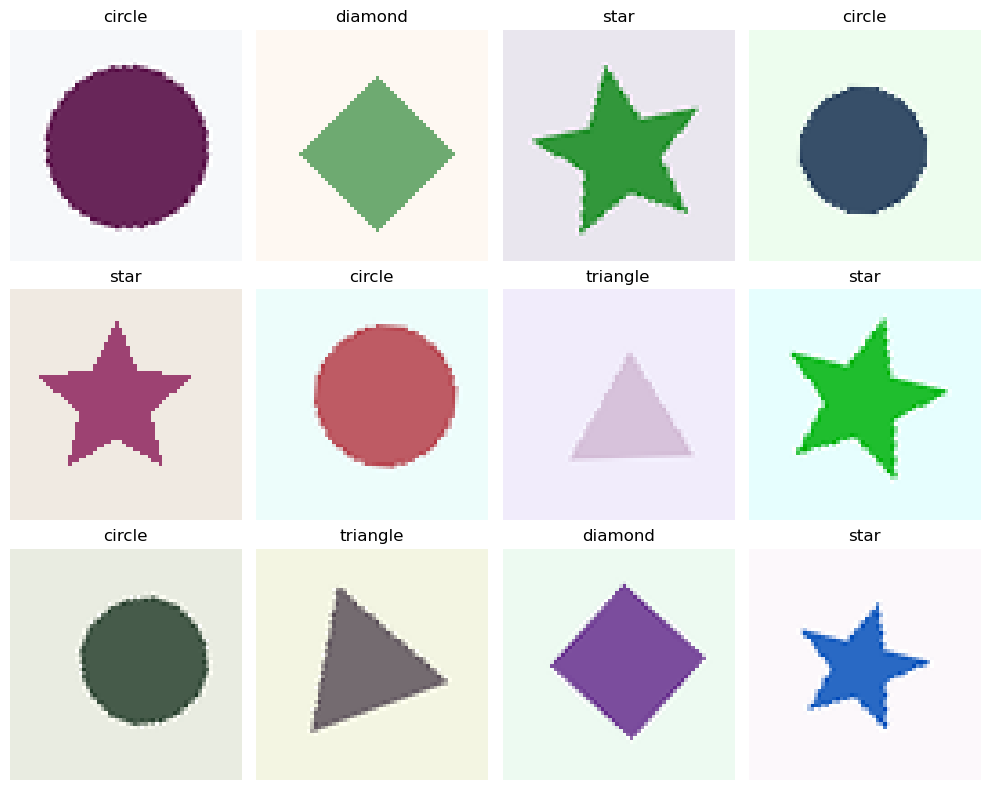

In [15]:
# Sample images show karne ke liye figure bana rahe hain
plt.figure(figsize=(10, 8))

# Training dataset ka ek batch le rahe hain
for images, labels in train_ds.take(1):

    # Pehli 12 images show kar rahe hain
    for index in range(12):

        # 3 rows aur 4 columns ka subplot
        plt.subplot(3, 4, index + 1)

        # RGB image show kar rahe hain
        plt.imshow(images[index].numpy().astype("uint8"))

        # Image ka label show kar rahe hain
        plt.title(class_names[int(labels[index])])

        # Axis hide kar rahe hain
        plt.axis("off")

plt.tight_layout()
plt.show()

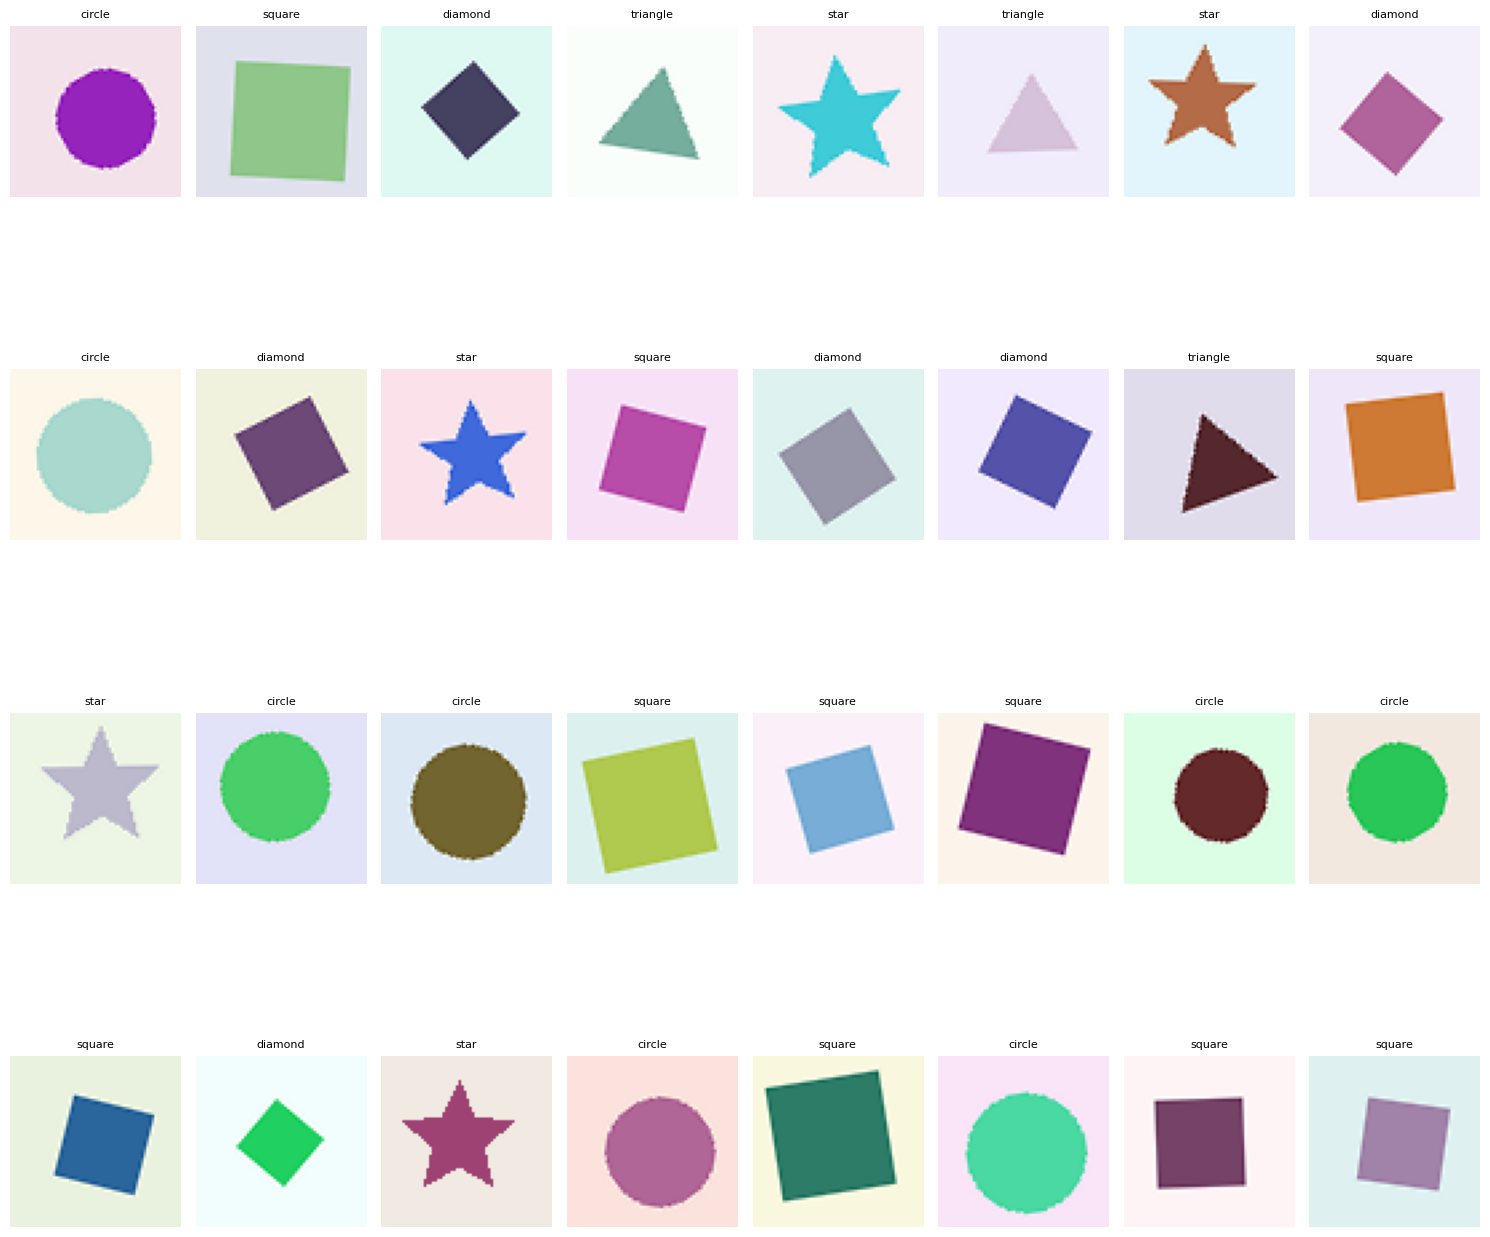

In [16]:
# Figure ka size define kar rahe hain
plt.figure(figsize=(15, 15))

# Sirf pehla batch le rahe hain
for images, labels in train_ds.take(1):

    # Batch ki jitni images hain un sab par loop chala rahe hain
    for index in range(len(images)):

        # 4 rows aur 8 columns ka subplot
        plt.subplot(4, 8, index + 1)

        # RGB image show kar rahe hain
        plt.imshow(images[index].numpy().astype("uint8"))

        # Image ka label show kar rahe hain
        plt.title(class_names[int(labels[index])], fontsize=8)

        # Axis hide kar rahe hain
        plt.axis("off")

plt.tight_layout()
plt.show()

## 10. Prefetch Apply Karna

`prefetch()` next batch ko background mein ready karta hai.

Is se training speed improve hoti hai.

In [17]:
# TensorFlow ko buffer size automatically choose karne de rahe hain
AUTOTUNE = tf.data.AUTOTUNE
AUTOTUNE

-1

In [18]:
# Training dataset ko faster bana rahe hain
train_ds = train_ds.prefetch(AUTOTUNE)

# Validation dataset ko faster bana rahe hain
validation_ds = validation_ds.prefetch(AUTOTUNE)

# Test dataset ko faster bana rahe hain
test_ds = test_ds.prefetch(AUTOTUNE)

## 11. CNN Model Start Karna

Hum `Sequential` model use kar rahe hain kyun ke layers ek ke baad ek chalengi.

In [20]:
# Sequential CNN model create kar rahe hain
model = tf.keras.Sequential()

## 12. Normalization Layer

Original pixels `0` se `255` tak hoti hain.

`1/255` se values `0` se `1` range mein aa jati hain.

In [21]:
# Pixel values ko 0 se 1 range mein convert kar rahe hain
model.add(
    tf.keras.layers.Rescaling(
        1.0 / 255,
        input_shape=(64, 64, 3)
    )
)

D:\Anaconda\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
import warnings
warnings.filterwarnings('ignore')

## 13. First Convolution Layer

- `32 filters`: 32 different features detect hongi
- `(3,3) kernel`: image ka chhota 3×3 area scan hoga
- `relu`: negative values ko zero karta hai

In [23]:
# Pehli convolution layer add kar rahe hain
model.add(
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    )
)

## 14. First Pooling Layer

`MaxPooling2D(2,2)` image ki feature map size ko half karta hai.

In [24]:
# Feature-map size reduce kar rahe hain
model.add(
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    )
)

## 15. Second Convolution Layer

`64 filters` pehli layer se zyada detailed features seekhenge.

In [25]:
# Doosri convolution layer add kar rahe hain
model.add(
    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    )
)

## 16. Second Pooling Layer

In [26]:
# Feature-map size dobara reduce kar rahe hain
model.add(
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    )
)

## 17. Flatten Layer

CNN ke 3D feature maps ko 1D vector mein convert karti hai.

In [27]:
# 3D features ko 1D vector mein convert kar rahe hain
model.add(
    tf.keras.layers.Flatten()
)

## 18. Dense Hidden Layer

`64 neurons` learned features ko combine karke final decision mein help karenge.

In [28]:
# Fully connected hidden layer add kar rahe hain
model.add(
    tf.keras.layers.Dense(
        units=64,
        activation="relu"
    )
)

## 19. Output Layer

Dataset mein 5 classes hain, is liye output layer mein `5 neurons` hain.

`softmax` har class ki probability deta hai.

In [29]:
# 5 shape classes ke liye output layer add kar rahe hain
model.add(
    tf.keras.layers.Dense(
        units=5,
        activation="softmax"
    )
)

## 20. Model Summary

In [30]:
# Model ki complete architecture show kar rahe hain
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         802,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 822,597 (3.14 MB)

 Trainable params: 822,597 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

## 21. Model Compile Karna

- `adam`: weights update karta hai
- `sparse_categorical_crossentropy`: integer multi-class labels ke liye
- `accuracy`: correct predictions ka ratio

In [31]:
# Model ko training ke liye ready kar rahe hain
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 22. Model Train Karna

`epochs=10` ka matlab model maximum 10 dafa complete training dataset dekhega.

In [32]:
# CNN model train kar rahe hain
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.3683 - loss: 1.4762 - val_accuracy: 0.6000 - val_loss: 1.1003
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.6600 - loss: 0.8755 - val_accuracy: 0.7067 - val_loss: 0.7505
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.7967 - loss: 0.5881 - val_accuracy: 0.8400 - val_loss: 0.5485
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.8483 - loss: 0.4385 - val_accuracy: 0.8667 - val_loss: 0.3739
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9217 - loss: 0.2421 - val_accuracy: 0.8800 - val_loss: 0.3277
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9417 - loss: 0.1799 - val_accuracy: 0.9000 - val_loss: 0.2681
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9583 - loss: 0.1299 - val_accuracy: 0.9000 - val_loss: 0.2241
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9700 - loss: 0.1148 - val_accuracy: 0.9133 - 

## 23. Accuracy Graph

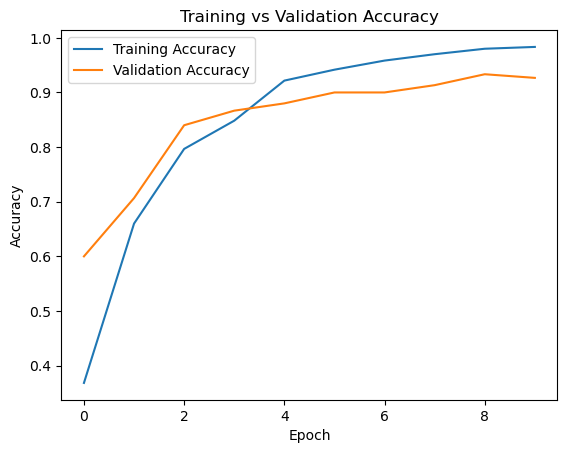

In [33]:
# Training accuracy plot kar rahe hain
plt.plot(history.history["accuracy"], label="Training Accuracy")

# Validation accuracy plot kar rahe hain
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

# Graph details
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 24. Loss Graph

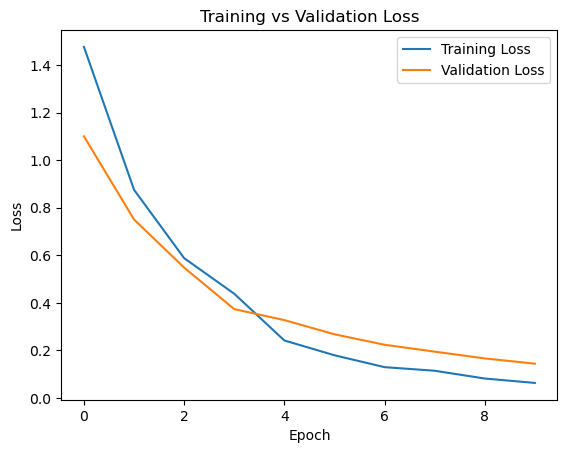

In [34]:
# Training loss plot kar rahe hain
plt.plot(history.history["loss"], label="Training Loss")

# Validation loss plot kar rahe hain
plt.plot(history.history["val_loss"], label="Validation Loss")

# Graph details
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 25. Test Dataset Evaluation

In [35]:
# Unseen test images par model evaluate kar rahe hain
test_loss, test_accuracy = model.evaluate(test_ds)

# Final result print kar rahe hain
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9133 - loss: 0.2191
Test Loss: 0.21909835934638977
Test Accuracy: 0.9133333563804626


## 26. Actual aur Predicted Images

In [42]:
# Test dataset ka ek batch le rahe hain
for images, labels in test_ds.take(5):

    # Images ki probabilities predict kar rahe hain
    probabilities = model.predict(images)

    # Highest probability wali class select kar rahe hain
    predictions = np.argmax(probabilities, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


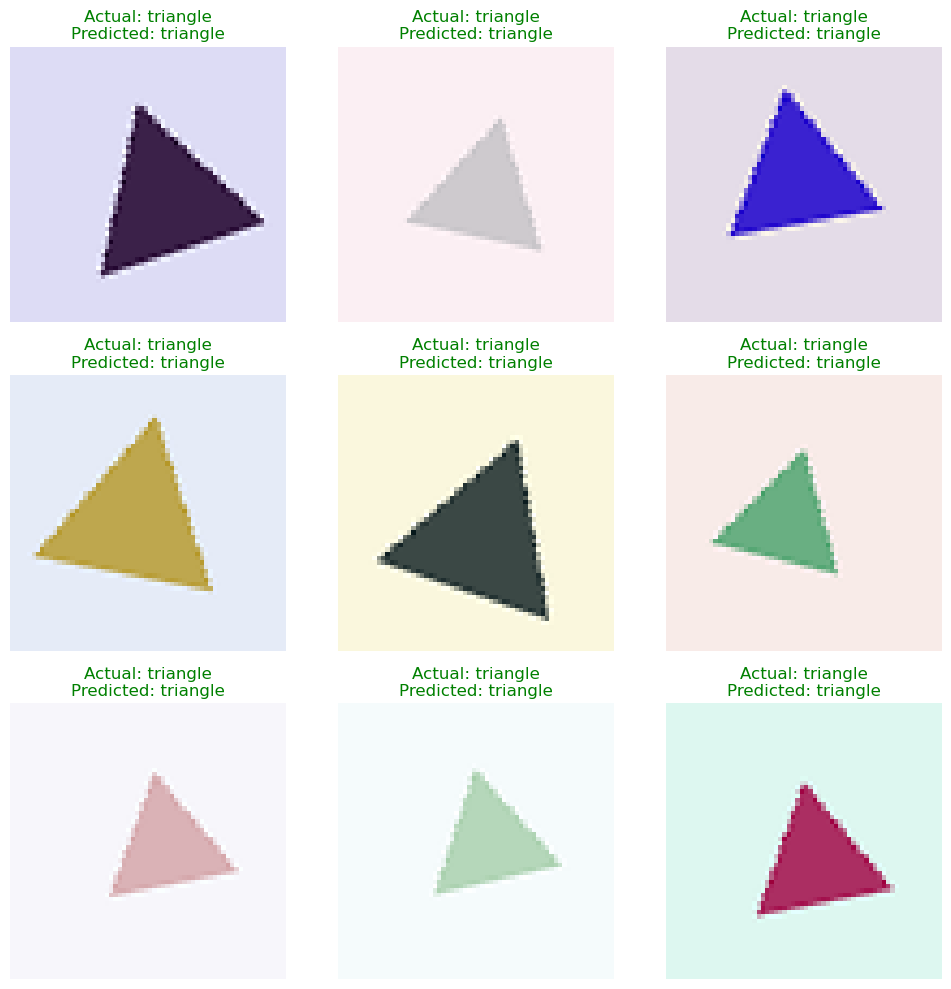

In [44]:
# Prediction images ke liye figure bana rahe hain
plt.figure(figsize=(10, 10))

# Pehli 9 images show kar rahe hain
for index in range(9):

    # 3 by 3 subplot
    plt.subplot(3, 3, index + 1)

    # RGB image show kar rahe hain
    plt.imshow(images[index].numpy().astype("uint8"))

    # Actual class
    actual = class_names[int(labels[index])]

    # Predicted class
    predicted = class_names[int(predictions[index])]

    # Correct ke liye green, wrong ke liye red
    title_color = "green" if actual == predicted else "red"

    # Title show kar rahe hain
    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}",
        color=title_color
    )

    plt.axis("off")

plt.tight_layout()
plt.show()